In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re

In [16]:
import glob
pickles = glob.glob('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_multiplane_dphi_test6/**/limits_summary.pkl', recursive=True)

dfs = []

for i, limit_pickle in enumerate(pickles):
    with open(limit_pickle, 'rb') as pkl_file:
        TABLE = pickle.load(pkl_file)
    dfs.append(TABLE)

TABLE = pd.concat(dfs)
TABLE

,obs,m2,m1,median,p1,p2
C1N2ML_M500_485_ct2_2018,None,0.331116,0.457788,0.683594,1.056896,1.595743
C1N2ML_M500_485_ct20_2018,None,0.374908,0.516940,0.761719,1.162503,1.730375
stopML_M1000_975_ct0p2_2018,None,0.000315,1.611446,2.578125,4.284027,6.923004
stopML_M1000_980_ct2_2018,None,0.203400,0.281212,0.419922,0.645888,0.973730
stopML_M1000_985_ct20_2018,None,0.243134,0.338169,0.501953,0.774063,1.164908
stopML_M1000_988_ct200_2018,None,2.014160,2.789234,4.125000,6.328285,9.460182
C1N2ML_M500_485_ct200_2018,None,1.106262,1.531966,2.265625,3.484794,5.213713


In [12]:
def parse_M(name: str) -> int:
    m = re.search(r"_M(\d+)", name)
    if not m:
        raise ValueError(f"Could not parse M from: {name}")
    return int(m.group(1))

def parse_ct(name: str) -> float:
    m = re.search(r"ct([0-9]+(?:p[0-9]+)?)", name)
    if not m:
        return np.nan
    return float(m.group(1).replace("p", "."))

def model_group(name: str) -> str:
    if name.startswith("C1N2"):
        return "C1N2"
    if name.startswith("stop"):
        return "stop"
    return "other"

In [13]:
obs_EXO_24_033_C1N2 = {
    'ct': (0.2, 2, 20, 200),
    'xs': (274.09, 61.364, 49.281, 133.81)
    }

obs_EXO_24_033_stop = {
    'ct': (0.2, 2, 20, 200),
    'xs': (8.499, 3.9022, 5.4943, 27.865)
    }

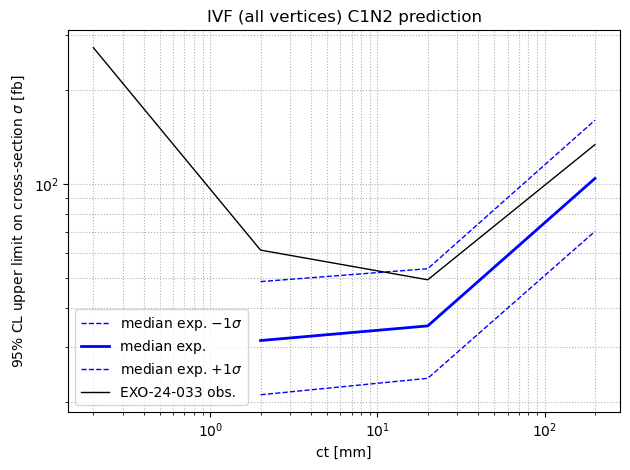

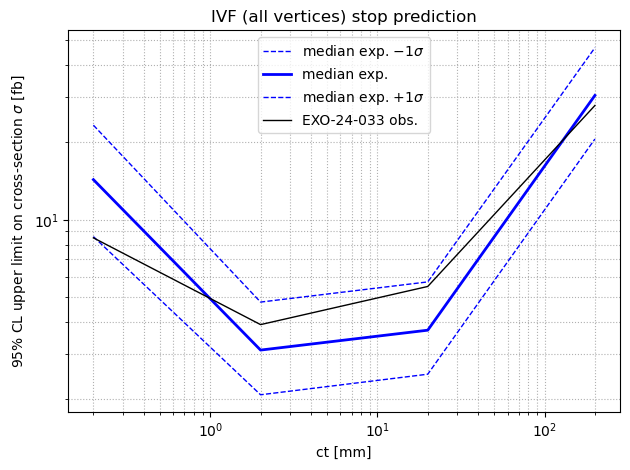

In [14]:
df = TABLE.copy()

xsec_map = {("C1N2", 500): 46.0,
            ("stop", 1000): 7.395}

df["M"] = [parse_M(s) for s in df.index]
df["ct"] = [parse_ct(s) for s in df.index]
df["model"] = [model_group(s) for s in df.index]
df["xs"] = [xsec_map.get((m, M), np.nan) for m, M in zip(df["model"], df["M"])]
df = df[df["model"].isin(["C1N2", "stop"])].dropna(subset=["ct"])

cols = ["m1", "median", "p1"]
linestyles = ["--", "-", "--"]
labels = [r"median exp. $-1 \sigma$", r"median exp.", r"median exp. $+1 \sigma$"]

for model in ["C1N2", "stop"]:
    sub = df[df["model"] == model].sort_values("ct")

    plt.figure()
    for i, c in enumerate(cols):
        lw=1 if i in [0,2] else 2
        plt.plot(sub["ct"], sub[c]*sub['xs'], label=labels[i], color='blue', linestyle=linestyles[i], lw=lw)

    if model == "C1N2":
        plt.plot(obs_EXO_24_033_C1N2['ct'], obs_EXO_24_033_C1N2['xs'], color="black", lw=1, linestyle="-", label='EXO-24-033 obs.')
    elif model == "stop":
        plt.plot(obs_EXO_24_033_stop['ct'], obs_EXO_24_033_stop['xs'], color="black", lw=1, linestyle="-", label='EXO-24-033 obs.')
    
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("ct [mm]")
    plt.ylabel(r"95% CL upper limit on cross-section $\sigma$ [fb]")
    plt.title(f'IVF (all vertices) {model} prediction')
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
plt.show()

# cms-style Equivalent

In [23]:
# With CMS style
import numpy as np
import ROOT
import cmsstyle as CMS
from array import array

ROOT.gROOT.SetBatch(True)

def _tgraph(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)  # log-safe
    x, y = x[m], y[m]
    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

# ---- your dataframe building (same as before) ----
df = TABLE.copy()

xsec_map = {("C1N2", 500): 46.0,
            ("stop", 1000): 7.395}

df["M"] = [parse_M(s) for s in df.index]
df["ct"] = [parse_ct(s) for s in df.index]
df["model"] = [model_group(s) for s in df.index]
df["xs"] = [xsec_map.get((m, M), np.nan) for m, M in zip(df["model"], df["M"])]

df = df[df["model"].isin(["C1N2", "stop"])].dropna(subset=["ct", "xs"])

cols       = ["m1", "median", "p1"]
labels     = ["median exp. -1#sigma", "median exp.", "median exp. +1#sigma"]
linestyles = [2, 1, 2]

CMS.SetExtraText("Simulation")
CMS.SetLumi(100)

_keep = []  # <-- IMPORTANT: keep ROOT objects alive for Jupyter display

for model in ["C1N2", "stop"]:
    sub = df[df["model"] == model].sort_values("ct")

    ys = {c: (sub[c].to_numpy(dtype=float) * sub["xs"].to_numpy(dtype=float)) for c in cols}
    x  = sub["ct"].to_numpy(dtype=float)

    all_y = np.concatenate([ys[c] for c in cols])
    all_y = all_y[np.isfinite(all_y) & (all_y > 0)]
    x_pos = x[np.isfinite(x) & (x > 0)]

    y_min = all_y.min() * 0.5
    y_max = all_y.max() * 2.0
    x_min = x_pos.min() * 0.7
    x_max = x_pos.max() * 1.3

    canv = CMS.cmsCanvas(
        f"c_{model}_{np.random.randint(1e9)}",
        x_min, x_max,
        y_min, y_max,
        "ct [mm]",
        "95% CL upper limit on cross section #sigma [fb]",
        extraSpace=0.01, iPos=0
    )
    canv.SetCanvasSize(1200, 900)   # width, height in pixels
    canv.SetLogx()
    canv.SetLogy()
    canv.Draw()

    hf = canv.GetListOfPrimitives().FindObject("hframe")
    hf.GetXaxis().SetLabelSize(0.035)
    hf.GetXaxis().SetTitleSize(0.04)
    hf.GetXaxis().SetTitleOffset(1.25)
    hf.GetYaxis().SetLabelSize(0.035)
    hf.GetYaxis().SetTitleSize(0.04)
    hf.GetYaxis().SetTitleOffset(1.35)

    # leg = CMS.cmsLeg(0.20, 0.62, 0.88, 0.82, textSize=0.035)
    leg = CMS.cmsLeg(0.40, 0.62, 0.88, 0.82, textSize=0.020)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.Draw()

    graphs = {}
    for i, c in enumerate(cols):
        g = _tgraph(x, ys[c])
        graphs[c] = g
        CMS.cmsDraw(g, "lsame", lwidth=2, lcolor=ROOT.kBlue, lstyle=linestyles[i])
        leg.AddEntry(g, labels[i], "l")

    if model == "C1N2":
        gobs = _tgraph(obs_EXO_24_033_C1N2["ct"], obs_EXO_24_033_C1N2["xs"])
    else:
        gobs = _tgraph(obs_EXO_24_033_stop["ct"], obs_EXO_24_033_stop["xs"])

    CMS.cmsDraw(gobs, "lsame", lwidth=2, lcolor=ROOT.kBlack, lstyle=1)
    leg.AddEntry(gobs, "EXO-24-033 obs.", "l")

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextFont(42)
    latex.SetTextSize(0.035)
    latex.DrawLatex(0.20, 0.86, f"IVF (all vertices) {model} prediction")

    canv.RedrawAxis()
    canv.Update()
    canv.Draw()
    # canv.SaveAs("limits.pdf")   # vector
    _keep.append((canv, leg, graphs, gobs, latex))  # <-- keep alive


Welcome to JupyROOT 6.28/00


ModuleNotFoundError: No module named 'cmsstyle'

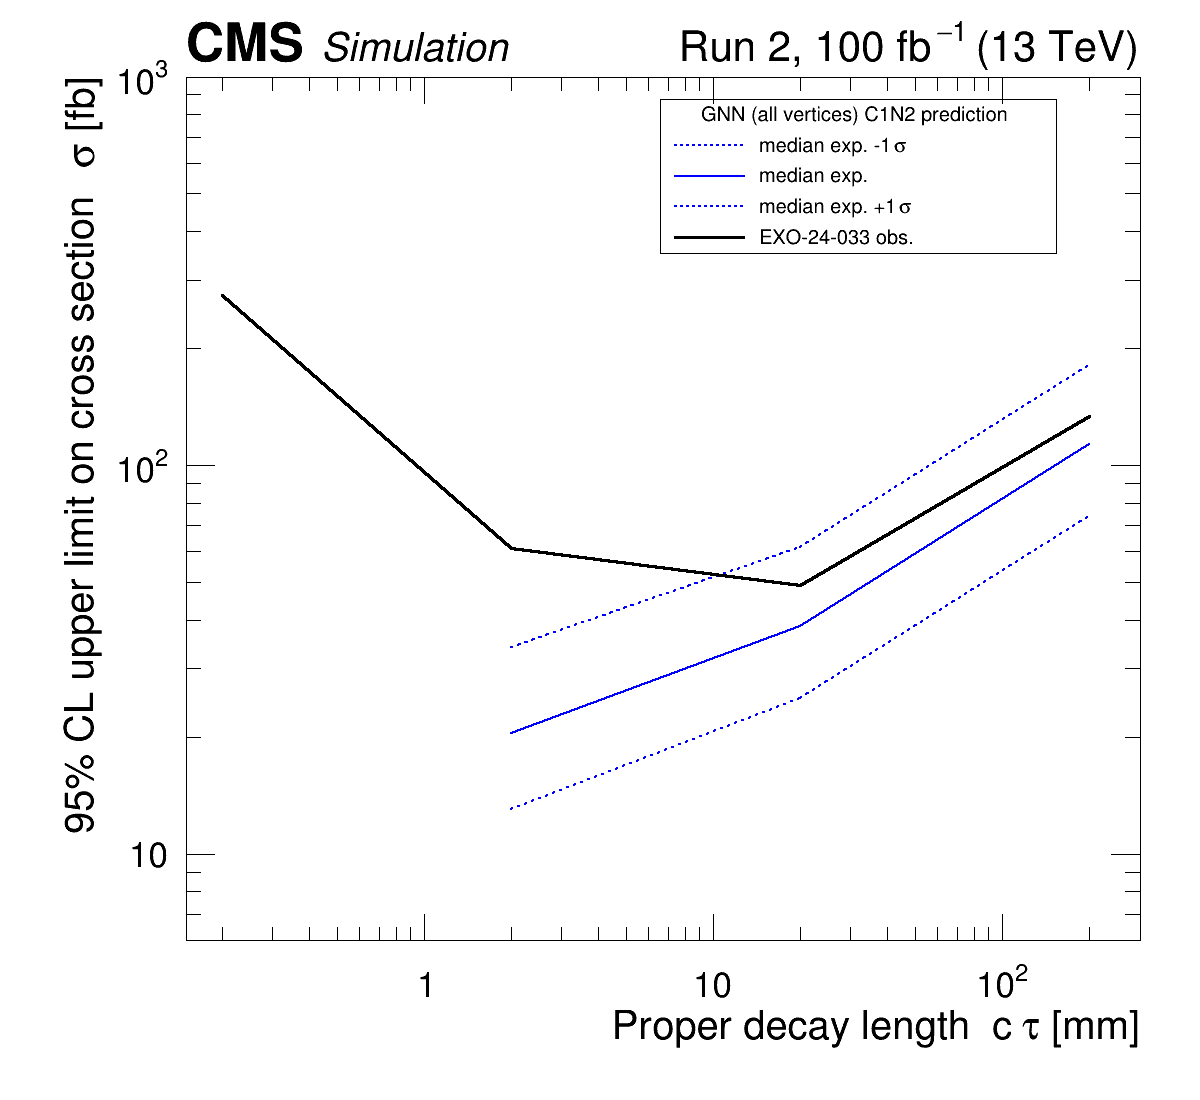

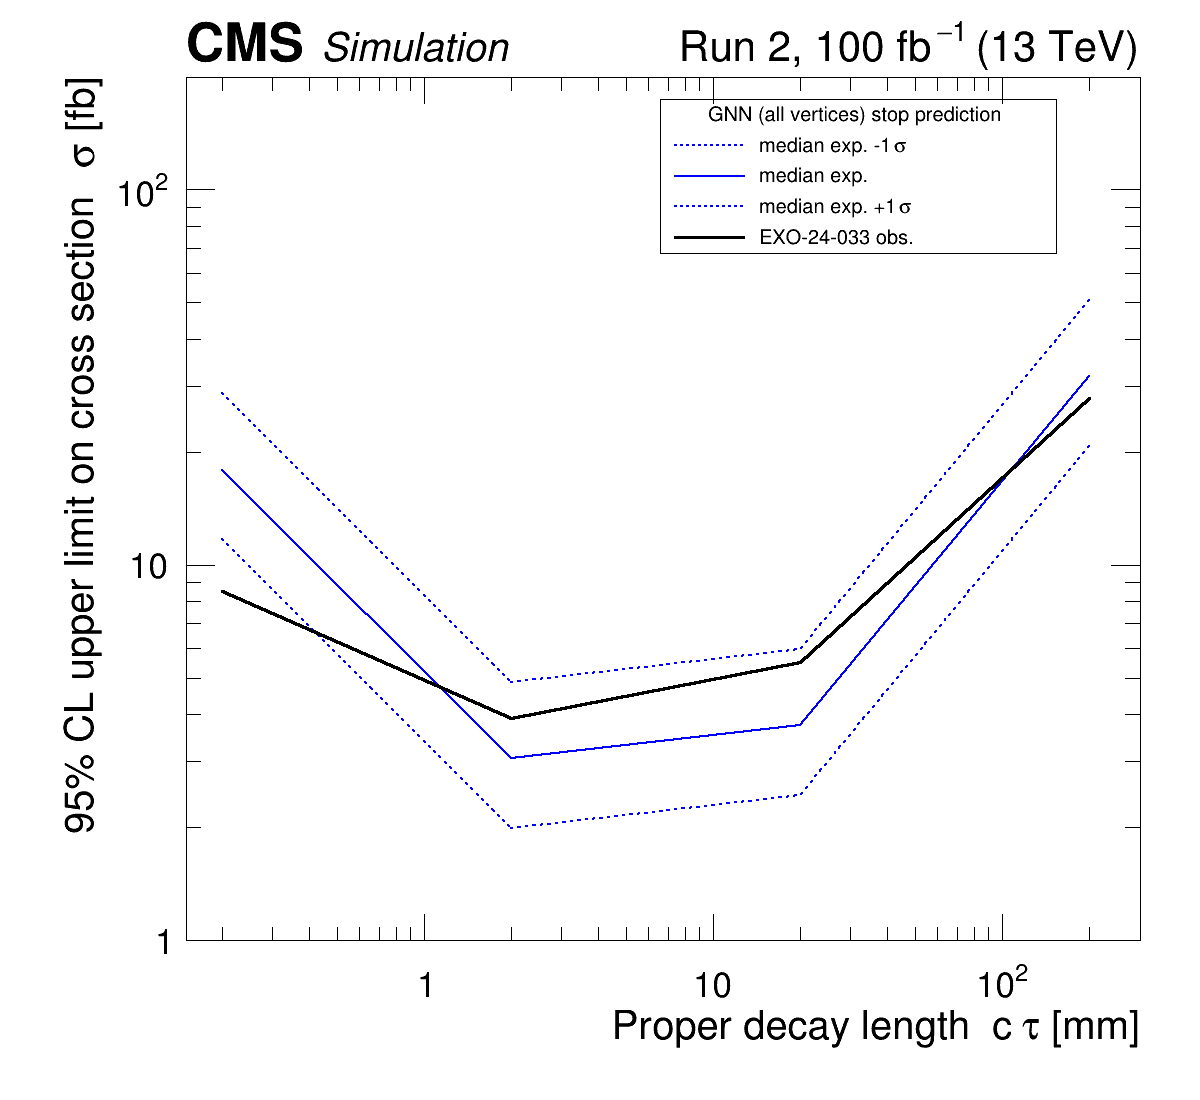

In [ ]:
# With CMS style
import numpy as np
import ROOT
import cmsstyle as CMS
from array import array

ROOT.gROOT.SetBatch(True)

def _tgraph(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)  # log-safe
    x, y = x[m], y[m]
    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

# ---- your dataframe building (same as before) ----
df = TABLE.copy()

xsec_map = {("C1N2", 500): 46.0,
            ("stop", 1000): 7.395}

df["M"] = [parse_M(s) for s in df.index]
df["ct"] = [parse_ct(s) for s in df.index]
df["model"] = [model_group(s) for s in df.index]
df["xs"] = [xsec_map.get((m, M), np.nan) for m, M in zip(df["model"], df["M"])]

df = df[df["model"].isin(["C1N2", "stop"])].dropna(subset=["ct", "xs"])

cols       = ["m1", "median", "p1"]
labels     = ["median exp. -1#sigma", "median exp.", "median exp. +1#sigma"]
linestyles = [2, 1, 2]

CMS.SetExtraText("Simulation")
CMS.SetLumi(100)

_keep = []  # keep ROOT objects alive (Jupyter)

for model in ["C1N2", "stop"]:
    sub = df[df["model"] == model].sort_values("ct")

    x  = sub["ct"].to_numpy(dtype=float)
    ys = {c: (sub[c].to_numpy(dtype=float) * sub["xs"].to_numpy(dtype=float)) for c in cols}

    all_y = np.concatenate([ys[c] for c in cols])
    all_y = all_y[np.isfinite(all_y) & (all_y > 0)]
    x_pos = x[np.isfinite(x) & (x > 0)]

    # y_min = all_y.min() * 0.5
    # y_max = all_y.max() * 10.0     # <-- BIG headroom so top band is empty on log-y
    if model == "C1N2":
        y_min = 6.
        y_max = 1_000.
    elif model == "stop":
        y_min = 1.
        y_max = 200.
    x_min = 0.15
    x_max = 300.
    # x_min = x_pos.min() * 0.7
    # x_max = x_pos.max() * 1.3

    canv = CMS.cmsCanvas(
        f"c_{model}_{np.random.randint(1e9)}",
        x_min, x_max,
        y_min, y_max,
        "Proper decay length  c#tau [mm]",
        "95% CL upper limit on cross section #sigma [fb]",
        extraSpace=0.01, iPos=0
    )
    canv.SetCanvasSize(1200, 1100)
    canv.SetLogx()
    canv.SetLogy()
    canv.Draw()

    hf = canv.GetListOfPrimitives().FindObject("hframe")
    hf.GetXaxis().SetLabelSize(0.035)
    hf.GetXaxis().SetTitleSize(0.04)
    hf.GetXaxis().SetTitleOffset(1.25)
    hf.GetYaxis().SetLabelSize(0.035)
    hf.GetYaxis().SetTitleSize(0.04)
    hf.GetYaxis().SetTitleOffset(1.35)

    # --- Draw curves first ---
    graphs = {}
    for i, c in enumerate(cols):
        g = _tgraph(x, ys[c])
        graphs[c] = g
        CMS.cmsDraw(g, "lsame", lwidth=2, lcolor=ROOT.kBlue, lstyle=linestyles[i])

    # EXO-24-033 observed
    if model == "C1N2":
        gobs = _tgraph(obs_EXO_24_033_C1N2["ct"], obs_EXO_24_033_C1N2["xs"])
    else:
        gobs = _tgraph(obs_EXO_24_033_stop["ct"], obs_EXO_24_033_stop["xs"])
    CMS.cmsDraw(gobs, "lsame", lwidth=3, lcolor=ROOT.kBlack, lstyle=1)

    # --- Legend box INSIDE the plotting frame, at the top empty band ---
    y_frame_top = 1.0 - canv.GetTopMargin()
    xL = canv.GetLeftMargin()
    xR = 1.0 - canv.GetRightMargin()

    y2 = y_frame_top - 0.02
    y1 = y2 - 0.14

    leg = CMS.cmsLeg(0.55, y1, 0.88, y2, textSize=0.020)
    leg.SetFillStyle(1001)
    leg.SetFillColor(ROOT.kWhite)
    leg.SetBorderSize(1)
    leg.SetLineColor(ROOT.kBlack)

    leg.SetHeader(f"GNN (all vertices) {model} prediction", "C")  # C = centered
    for c, lab in zip(cols, labels):
        leg.AddEntry(graphs[c], lab, "l")
    leg.AddEntry(gobs, "EXO-24-033 obs.", "l")
    leg.Draw()

    # separator line under the legend band (to look like a separate box)
    # sep = ROOT.TLine()
    # sep.SetLineWidth(1)
    # sep.DrawLineNDC(xL, y1 - 0.01, xR, y1 - 0.01)

    # annotation inside plot, below the top band
    # latex = ROOT.TLatex()
    # latex.SetNDC()
    # latex.SetTextFont(42)
    # latex.SetTextSize(0.040)

    canv.RedrawAxis()
    canv.Update()
    canv.Draw()

    _keep.append((canv, leg, graphs, gobs, latex))
